In [2]:
#Install required libraries
!pip install datasets nltk scikit-learn

In [3]:
#Import Required Libraries
import re
import string
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

from datasets import load_dataset

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

nltk.download('stopwords')
nltk.download('wordnet')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


Using device: cuda


In [4]:
#Load IMDB dataset
dataset = load_dataset("stanfordnlp/imdb")
train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])
print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)
train_df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train Shape: (25000, 2)
Test Shape: (25000, 2)


,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


label
0    12500
1    12500
Name: count, dtype: int64


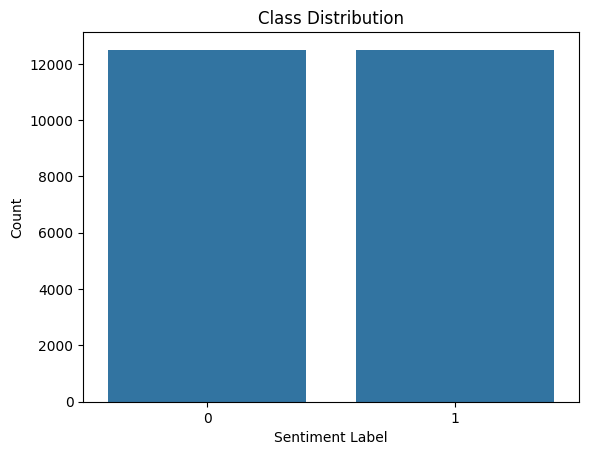

In [5]:
#Analyze class distribution
print(train_df["label"].value_counts())
sns.countplot(x=train_df["label"])
plt.title("Class Distribution")
plt.xlabel("Sentiment Label")
plt.ylabel("Count")
plt.show()

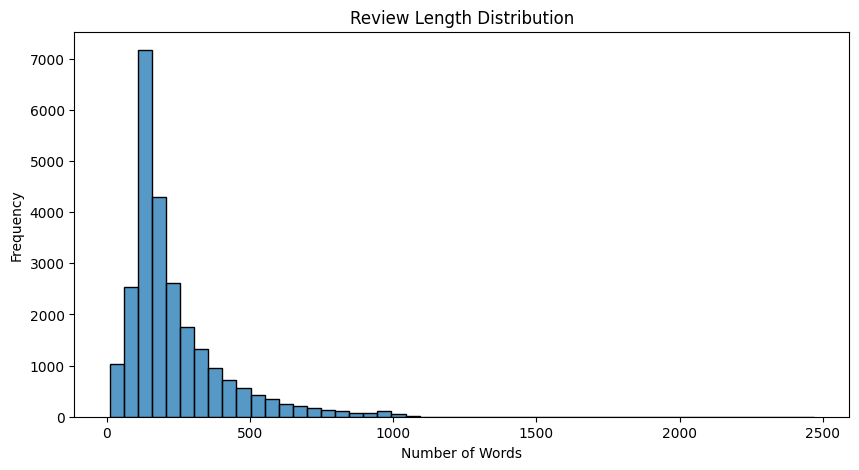

,review_length
count,25000.000000
mean,233.787200
std,173.733032
min,10.000000
25%,127.000000
50%,174.000000
75%,284.000000
max,2470.000000


In [6]:
#Review Length Distribution
train_df["review_length"] = train_df["text"].apply(lambda x: len(x.split()))
plt.figure(figsize=(10,5))
sns.histplot(train_df["review_length"], bins=50)
plt.title("Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()
train_df["review_length"].describe()

In [7]:
#Check Missing Values
print(train_df.isnull().sum())
print(test_df.isnull().sum())

text             0
label            0
review_length    0
dtype: int64
text     0
label    0
dtype: int64


In [8]:
#Text Preprocessing Function
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):

    # Convert text to lowercase
    text = text.lower()
    # Remove punctuation
    text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)
    # Remove numbers
    text = re.sub(r"\d+", "", text)
    # Split into words
    words = text.split()
    cleaned_words = []
    for word in words:
        if word not in stop_words:
            word = lemmatizer.lemmatize(word)
            cleaned_words.append(word)

    return " ".join(cleaned_words)

In [9]:
#Applying text preprocessing
train_df["clean_text"] = train_df["text"].apply(preprocess_text)
test_df["clean_text"] = test_df["text"].apply(preprocess_text)
train_df[["text","clean_text"]].head()

,text,clean_text
0,I rented I AM CURIOUS-YELLOW from my video sto...,rented curiousyellow video store controversy s...
1,"""I Am Curious: Yellow"" is a risible and preten...",curious yellow risible pretentious steaming pi...
2,If only to avoid making this type of film in t...,avoid making type film future film interesting...
3,This film was probably inspired by Godard's Ma...,film probably inspired godard masculin féminin...
4,"Oh, brother...after hearing about this ridicul...",oh brotherafter hearing ridiculous film umptee...


In [10]:
#Convert text into tokens and create a vocabulary dictionary
tokenized_reviews = [review.split() for review in train_df["clean_text"]]

word_counter = Counter()

for review in tokenized_reviews:
    word_counter.update(review)

# Keep most frequent words
VOCAB_SIZE = 20000
most_common_words = word_counter.most_common(VOCAB_SIZE - 2)
word_to_index = {"<PAD>":0, "<UNK>":1}
for i,(word,count) in enumerate(most_common_words):
    word_to_index[word] = i + 2
print("Vocabulary size:", len(word_to_index))

Vocabulary size: 20000


In [11]:
# Convert each review into a sequence of numbers using the vocabulary.

MAX_LENGTH = 200

def text_to_sequence(text):

    tokens = text.split()

    sequence = []
    for word in tokens:
        if word in word_to_index:
            sequence.append(word_to_index[word])
        else:
            sequence.append(word_to_index["<UNK>"])

    # Pad or truncate sequence
    if len(sequence) < MAX_LENGTH:
        sequence += [0] * (MAX_LENGTH - len(sequence))
    else:
        sequence = sequence[:MAX_LENGTH]

    return sequence


train_sequences = [text_to_sequence(text) for text in train_df["clean_text"]]
test_sequences = [text_to_sequence(text) for text in test_df["clean_text"]]

In [12]:
# Create a custom dataset class for PyTorch.

class IMDBDataset(Dataset):

    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):

        x = torch.tensor(self.sequences[idx], dtype=torch.long)
        y = torch.tensor(self.labels[idx], dtype=torch.float)
        return x, y

train_dataset = IMDBDataset(train_sequences, train_df["label"].values)
test_dataset = IMDBDataset(test_sequences, test_df["label"].values)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

In [13]:
# Baseline sentiment classifier.
# Architecture:
# Embedding -> Average Pooling -> Dense -> Output

class BaselineModel(nn.Module):

    def __init__(self, vocab_size, embedding_dim):

        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.fc1 = nn.Linear(embedding_dim, 64)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(64,1)

    def forward(self, x):

        embedded = self.embedding(x)
        pooled = embedded.mean(dim=1)
        x = torch.relu(self.fc1(pooled))
        x = self.dropout(x)
        x = torch.sigmoid(self.fc2(x))
        return x

baseline_model = BaselineModel(len(word_to_index),128).to(device)

In [14]:
# Experimental model using Bidirectional LSTM.

class BiLSTMModel(nn.Module):

    def __init__(self, vocab_size, embedding_dim):

        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embedding_dim,
            64,
            batch_first=True,
            bidirectional=True
        )
        self.fc1 = nn.Linear(128,64)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(64,1)

    def forward(self,x):

        embedded = self.embedding(x)
        lstm_out,_ = self.lstm(embedded)
        pooled = lstm_out.mean(dim=1)
        x = torch.relu(self.fc1(pooled))
        x = self.dropout(x)
        x = torch.sigmoid(self.fc2(x))
        return x

experimental_model = BiLSTMModel(len(word_to_index),128).to(device)

In [15]:
# Training function to train both baseline and experimental model

def train_model(model, train_loader, epochs=10):

    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):

        model.train()
        total_loss = 0

        for X,y in train_loader:

            X = X.to(device)
            y = y.to(device).unsqueeze(1)
            optimizer.zero_grad()
            outputs = model(X)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1} Loss: {total_loss/len(train_loader):.4f}")

In [16]:
# Train the baseline model.

train_model(baseline_model, train_loader)

Epoch 1 Loss: 0.5327
Epoch 2 Loss: 0.3050
Epoch 3 Loss: 0.2281
Epoch 4 Loss: 0.1791
Epoch 5 Loss: 0.1398
Epoch 6 Loss: 0.1111
Epoch 7 Loss: 0.0854
Epoch 8 Loss: 0.0656
Epoch 9 Loss: 0.0495
Epoch 10 Loss: 0.0369


In [17]:
# Train the experimental model.

train_model(experimental_model, train_loader)

Epoch 1 Loss: 0.5621
Epoch 2 Loss: 0.3872
Epoch 3 Loss: 0.2675
Epoch 4 Loss: 0.1991
Epoch 5 Loss: 0.1405
Epoch 6 Loss: 0.0913
Epoch 7 Loss: 0.0609
Epoch 8 Loss: 0.0390
Epoch 9 Loss: 0.0271
Epoch 10 Loss: 0.0240


In [18]:
# Evaluation Function

def evaluate_model(model, test_loader):

    model.eval()

    predictions = []
    actuals = []

    with torch.no_grad():

        for X,y in test_loader:

            X = X.to(device)
            outputs = model(X)
            preds = (outputs.cpu().numpy() > 0.5).astype(int)
            predictions.extend(preds)
            actuals.extend(y.numpy())

    return actuals, predictions

              precision    recall  f1-score   support

         0.0       0.83      0.86      0.84     12500
         1.0       0.86      0.82      0.84     12500

    accuracy                           0.84     25000
   macro avg       0.84      0.84      0.84     25000
weighted avg       0.84      0.84      0.84     25000



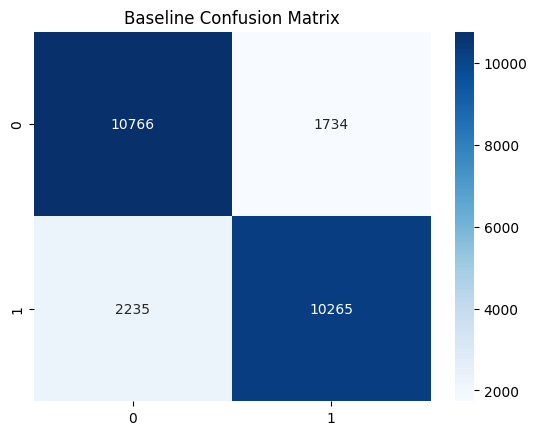

In [19]:
# Evaluate baseline model performance.

y_true, y_pred = evaluate_model(baseline_model, test_loader)
print(classification_report(y_true, y_pred))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Baseline Confusion Matrix")
plt.show()

              precision    recall  f1-score   support

         0.0       0.83      0.86      0.84     12500
         1.0       0.85      0.82      0.84     12500

    accuracy                           0.84     25000
   macro avg       0.84      0.84      0.84     25000
weighted avg       0.84      0.84      0.84     25000



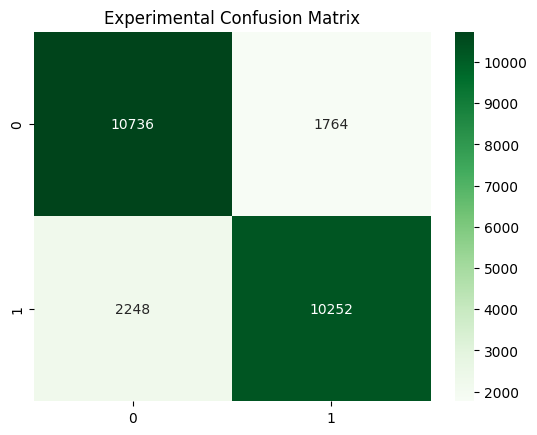

In [20]:
# Evaluate experimental model performance.

y_true, y_pred = evaluate_model(experimental_model, test_loader)
print(classification_report(y_true, y_pred))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("Experimental Confusion Matrix")
plt.show()

In [21]:
# Compare the accuracy of both models.

baseline_true, baseline_pred = evaluate_model(baseline_model, test_loader)
experimental_true, experimental_pred = evaluate_model(experimental_model, test_loader)
print("Baseline Accuracy:", accuracy_score(baseline_true, baseline_pred))
print("Experimental Accuracy:", accuracy_score(experimental_true, experimental_pred))

Baseline Accuracy: 0.84124
Experimental Accuracy: 0.83952
